<a href="https://colab.research.google.com/github/emilheroyt/Bachelor-Thesis-Stress-Testing-Robustness-of-SOTA-Point-Trackers/blob/main/experiment2/Experiment2_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Zelle 1 – Die zwei erweiterten CSVs laden:

In [7]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, numpy as np

base = "/content/drive/MyDrive/ba_results/"
df_exp2 = pd.concat([pd.read_csv(base + "cotracker3_all_videos_v4.csv"),
                     pd.read_csv(base + "tapnext_all_videos_v4.csv")], ignore_index=True)
df_exp2["visibility_bias"] = df_exp2["false_visible_rate"] - df_exp2["false_occluded_rate"]  # >0 überkonfident, <0 konservativ
df_exp2.to_csv(base + "experiment2_combined_v4.csv", index=False)

blur_order = ["none", "medium", "strong"]
metrics2 = ["occlusion_accuracy", "outlier_magnitude", "outlier_ratio_vs_gt",
            "false_visible_rate", "false_occluded_rate", "visibility_bias"]
print(df_exp2.groupby(["model", "blur"])[metrics2].agg(["mean", "median"]).round(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                  occlusion_accuracy         outlier_magnitude         \
                                mean  median              mean median   
model      blur                                                         
CoTracker3 medium             80.375  87.428             6.605  6.147   
           none               88.131  89.689             7.296  6.427   
           strong             66.903  75.873             5.721  6.290   
TapNext    medium             77.256  83.896            12.744  7.099   
           none               91.340  93.194             9.179  7.883   
           strong             62.050  63.735            18.426  6.608   

                  outlier_ratio_vs_gt        false_visible_rate         \
                                 mean median               mean median   
model      blur                                                  

Zelle 2 – Vergleichsplots für alle drei Experiment-2-Metriken:

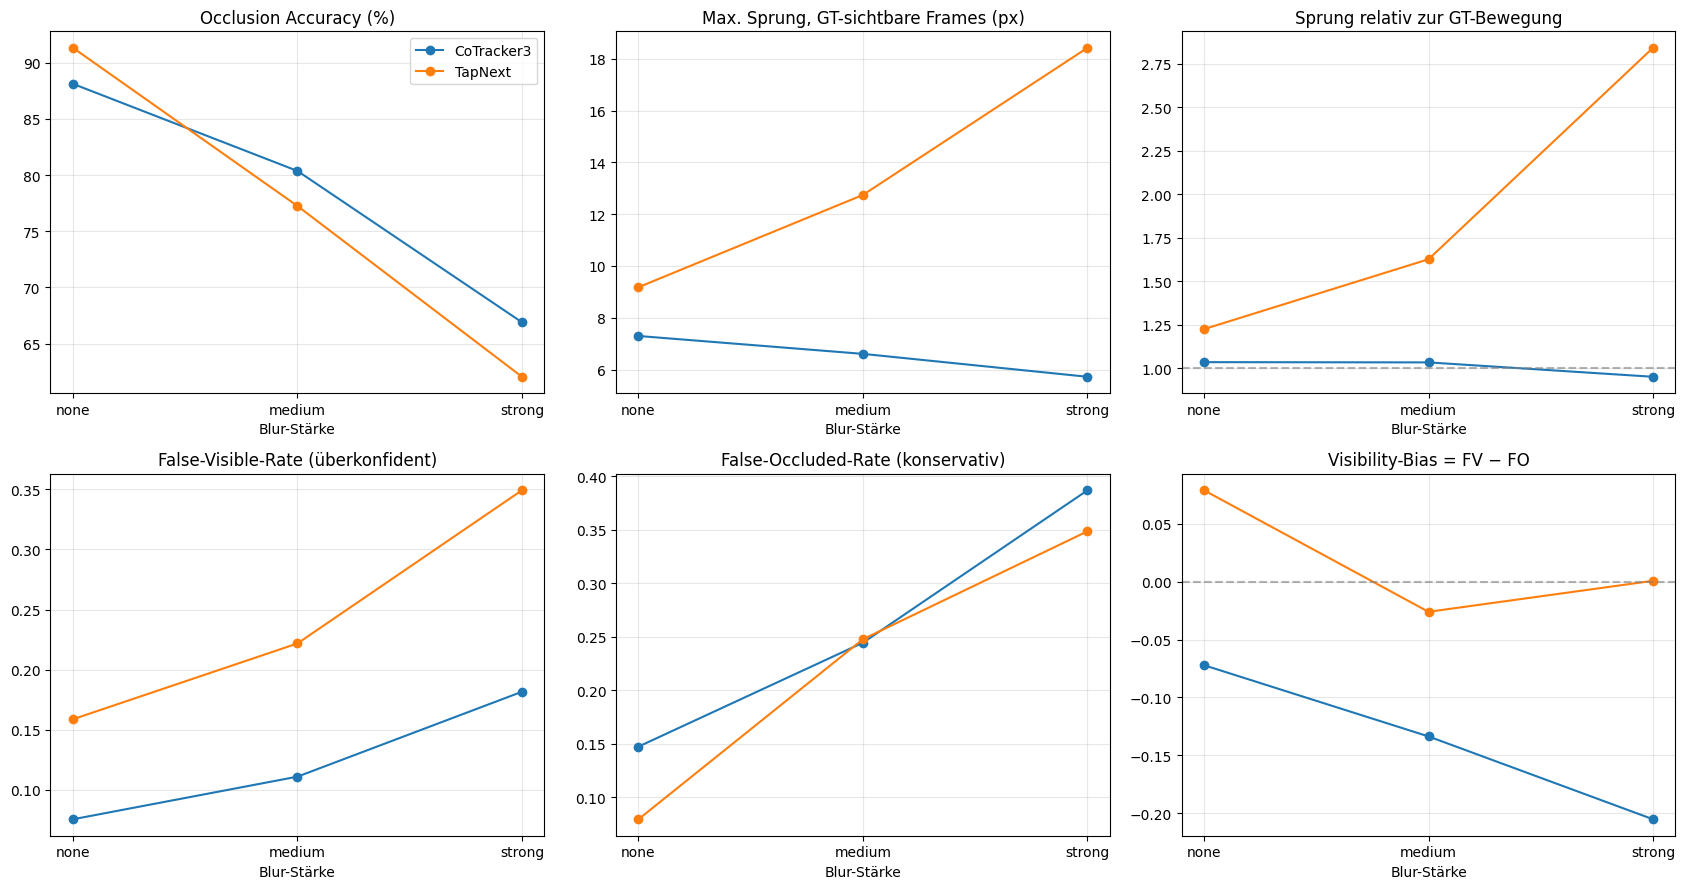

In [8]:
import matplotlib.pyplot as plt
titles = {"occlusion_accuracy": "Occlusion Accuracy (%)",
          "outlier_magnitude": "Max. Sprung, GT-sichtbare Frames (px)",
          "outlier_ratio_vs_gt": "Sprung relativ zur GT-Bewegung",
          "false_visible_rate": "False-Visible-Rate (überkonfident)",
          "false_occluded_rate": "False-Occluded-Rate (konservativ)",
          "visibility_bias": "Visibility-Bias = FV − FO"}
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, metric in zip(axes.ravel(), metrics2):
    s = df_exp2.groupby(["model", "blur"])[metric].mean().reset_index()
    for m in ["CoTracker3", "TapNext"]:
        sub = s[s.model == m].set_index("blur").reindex(blur_order)
        ax.plot(blur_order, sub[metric], marker="o", label=m)
    if metric == "outlier_ratio_vs_gt": ax.axhline(1.0, color="gray", ls="--", alpha=.6)
    if metric == "visibility_bias": ax.axhline(0.0, color="gray", ls="--", alpha=.6)
    ax.set_title(titles[metric]); ax.set_xlabel("Blur-Stärke"); ax.grid(alpha=.3)
axes[0, 0].legend(); plt.tight_layout()
plt.savefig(base + "experiment2_comparison_v4.png", dpi=150); plt.show()
df_exp2.groupby(["model", "blur"])[metrics2].mean().round(3).to_csv(base + "experiment2_summary_table_v4.csv")

Zelle 3 - gepaarte Tests für Experiment 2

In [9]:
from scipy.stats import wilcoxon
for metric in ["outlier_magnitude", "outlier_ratio_vs_gt", "false_visible_rate", "false_occluded_rate", "visibility_bias"]:
    for level in blur_order:
        a = df_exp2[(df_exp2.model == "TapNext") & (df_exp2.blur == level)].set_index("video")[metric]
        b = df_exp2[(df_exp2.model == "CoTracker3") & (df_exp2.blur == level)].set_index("video")[metric]
        d = (a - b).dropna()
        print(f"{metric:20s} | {level:6s}: TapNext − CoTracker3 = {d.mean():7.3f} ± {1.96*d.std(ddof=1)/np.sqrt(len(d)):.3f} | p = {wilcoxon(d).pvalue:.4f}")
    print()

outlier_magnitude    | none  : TapNext − CoTracker3 =   1.883 ± 1.675 | p = 0.0000
outlier_magnitude    | medium: TapNext − CoTracker3 =   6.139 ± 4.216 | p = 0.0002
outlier_magnitude    | strong: TapNext − CoTracker3 =  12.705 ± 8.816 | p = 0.0310

outlier_ratio_vs_gt  | none  : TapNext − CoTracker3 =   0.190 ± 0.142 | p = 0.0002
outlier_ratio_vs_gt  | medium: TapNext − CoTracker3 =   0.593 ± 0.369 | p = 0.0005
outlier_ratio_vs_gt  | strong: TapNext − CoTracker3 =   1.893 ± 1.337 | p = 0.0197

false_visible_rate   | none  : TapNext − CoTracker3 =   0.083 ± 0.037 | p = 0.0003
false_visible_rate   | medium: TapNext − CoTracker3 =   0.111 ± 0.076 | p = 0.0074
false_visible_rate   | strong: TapNext − CoTracker3 =   0.168 ± 0.137 | p = 0.0345

false_occluded_rate  | none  : TapNext − CoTracker3 =  -0.068 ± 0.030 | p = 0.0000
false_occluded_rate  | medium: TapNext − CoTracker3 =   0.003 ± 0.058 | p = 0.4388
false_occluded_rate  | strong: TapNext − CoTracker3 =  -0.038 ± 0.098 | p = 0.4161



Qualitative Jitter Comparison:

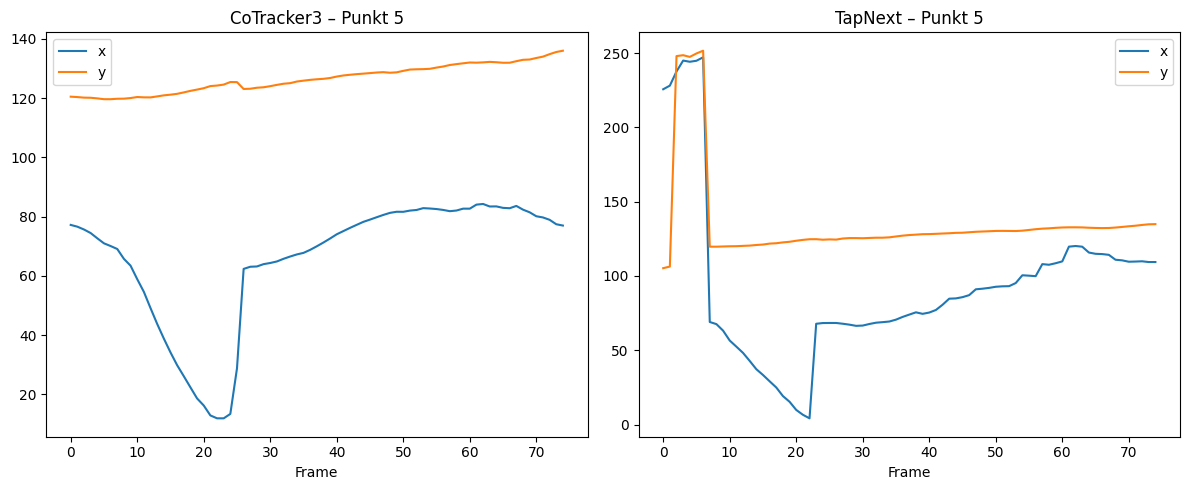

In [10]:
import numpy as np
import matplotlib.pyplot as plt

traj_ct3 = np.load(base + "cotracker3_traj_video1_strong.npy")
traj_tapnext = np.load(base + "tapnext_traj_video1_strong.npy")

point_idx = 5

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(traj_ct3[point_idx, :, 0], label="x")
axes[0].plot(traj_ct3[point_idx, :, 1], label="y")
axes[0].set_title(f"CoTracker3 – Punkt {point_idx}")
axes[0].set_xlabel("Frame")
axes[0].legend()

axes[1].plot(traj_tapnext[point_idx, :, 0], label="x")
axes[1].plot(traj_tapnext[point_idx, :, 1], label="y")
axes[1].set_title(f"TapNext – Punkt {point_idx}")
axes[1].set_xlabel("Frame")
axes[1].legend()

plt.tight_layout()
plt.savefig(base + "qualitative_jitter_comparison.png", dpi=150)
plt.show()

Für jeden der 20 Punkte maximale Sprungdistanz testen:

In [11]:
diffs_ct3 = np.linalg.norm(traj_ct3[:, 1:] - traj_ct3[:, :-1], axis=-1)  # (20, T-1)
diffs_tapnext = np.linalg.norm(traj_tapnext[:, 1:] - traj_tapnext[:, :-1], axis=-1)

max_jump_ct3 = diffs_ct3.max(axis=1)
max_jump_tapnext = diffs_tapnext.max(axis=1)

contrast = max_jump_tapnext - max_jump_ct3
best_point = np.argmax(contrast)

print("Bester Kontrast-Punkt:", best_point)
print("CoTracker3 max. Sprung:", max_jump_ct3[best_point])
print("TapNext max. Sprung:", max_jump_tapnext[best_point])

Bester Kontrast-Punkt: 8
CoTracker3 max. Sprung: 11.815926
TapNext max. Sprung: 224.43611


Point Index = 8:

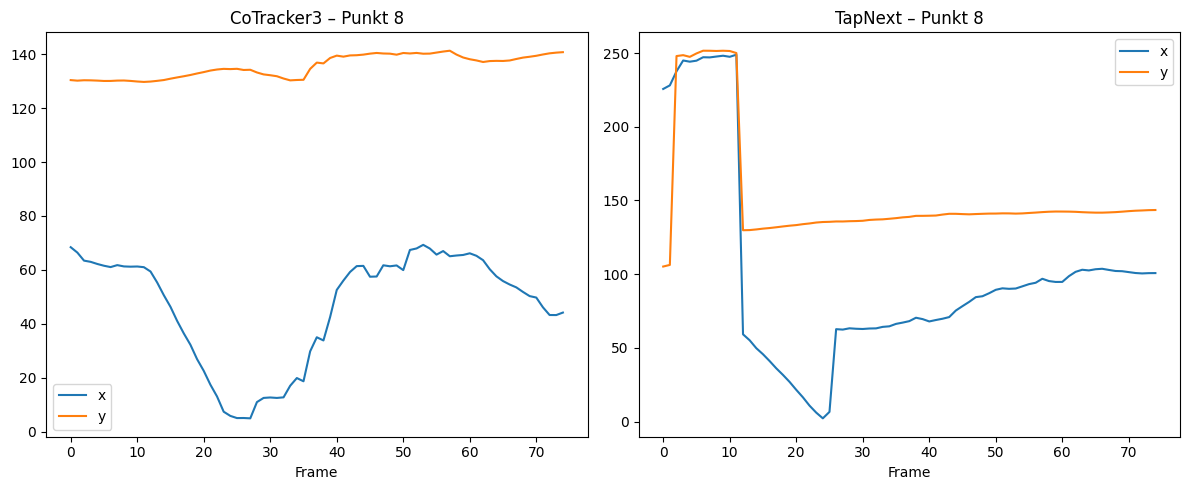

In [12]:
point_idx = 8

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(traj_ct3[point_idx, :, 0], label="x")
axes[0].plot(traj_ct3[point_idx, :, 1], label="y")
axes[0].set_title(f"CoTracker3 – Punkt {point_idx}")
axes[0].set_xlabel("Frame")
axes[0].legend()

axes[1].plot(traj_tapnext[point_idx, :, 0], label="x")
axes[1].plot(traj_tapnext[point_idx, :, 1], label="y")
axes[1].set_title(f"TapNext – Punkt {point_idx}")
axes[1].set_xlabel("Frame")
axes[1].legend()

plt.tight_layout()
plt.savefig(base + "qualitative_jitter_comparison.png", dpi=150)
plt.show()

In [15]:
import pandas as pd
base = "/content/drive/MyDrive/ba_results/"
tn = pd.read_csv(base + "tapnext_all_videos_v4.csv")
ct = pd.read_csv(base + "cotracker3_all_videos_v4.csv")
m = tn[tn.blur == "strong"][["video", "outlier_ratio_vs_gt", "outlier_magnitude"]].merge(
    ct[ct.blur == "strong"][["video", "outlier_ratio_vs_gt", "outlier_magnitude"]],
    on="video", suffixes=("_tapnext", "_cotracker3"))
m["contrast"] = m["outlier_ratio_vs_gt_tapnext"] - m["outlier_ratio_vs_gt_cotracker3"]
print(m.sort_values("contrast", ascending=False).head(5).round(2))

    video  outlier_ratio_vs_gt_tapnext  outlier_magnitude_tapnext  \
22     22                        13.08                      79.37   
14     14                        14.31                      63.22   
29     29                        12.64                      76.82   
26     26                         9.92                      67.44   
9       9                         4.60                      82.76   

    outlier_ratio_vs_gt_cotracker3  outlier_magnitude_cotracker3  contrast  
22                            0.97                          5.90     12.11  
14                            3.12                         13.47     11.19  
29                            1.69                         10.13     10.95  
26                            1.00                          6.92      8.93  
9                             0.69                         10.30      3.91  
